Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/m

## Reading in global data

## Running pipeline (loading data, run DMD, recover modes)

# Results_dict

Results dict is a dictionary containing the results for a single run of DMD.

It is split into 4 kinds of records [record_key]:

- "ideal"
- "resolved"
- "background"
- "ensemble" = ["1", "2", ..., "n_ensemble"]

If a record converged/ obtained modes (i.e. opDMD LS convergence), a result is returned (see below), False if not.

each 'record' result data set stores the following for each mode [record_key]["mode_key"]:

- whether match was made (see below) or not (will be False)
- "match_period" = what is the period of the DMD mode matched
- "period_error" = waht is the fractional error in period to matched mode
- "similarity" = similarity of complex phasor recovered vs true input

as well as the overall modes recovered for that run [record_key]["match_count"]

In [31]:
# running on background field only


gnm_background = CHAOS_Full_SV_Record_Obtain()
# nmax values to test
nmax_list = np.arange(5, 8, 2)

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 20, 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":3,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":False,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}

num_modes_heat_map = np.zeros((len(nmax_list), len(svd_rank_list)))

# for each nmax to be tested
for n_idx, nmax in enumerate(nmax_list):

    # for each svd rank to be tested
    for r_idx, svd_rank in enumerate(svd_rank_list):

        A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax)
        gnm_background_truncate = Truncate_Gauss_Coeffs(gnm_background, tmax=nmax)

        # projecting to grid
        background_record = A_r @ gnm_background_truncate.T
        
        # run DMD on background to get
        recovered_modes = Run_DMD(background_record, times_used_relative, svd_rank=svd_rank, dmd_settings=dmd_settings)

        recovered_periods = np.asarray(recovered_modes["periods"])
        feasible_mask = ((recovered_periods < 100) & (recovered_periods > 3))

        feasible_periods = recovered_periods[feasible_mask]
        num_modes_heat_map[n_idx, r_idx] = len(feasible_periods)



/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 113179.57036965269. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:639: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 125990.1358612893. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


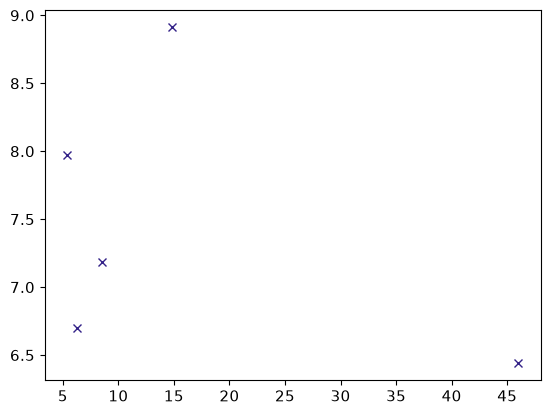

In [89]:
# make a set of 'recovered patterns' from var 99.9% and nmax = 9 - these act as like the input phasors
dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":6,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":False,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}
nmax_control = 9
svd_rank_control = 0.999

A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax_control)
gnm_background_truncate = Truncate_Gauss_Coeffs(gnm_background, tmax=nmax_control)

# projecting to grid
background_record = A_r @ gnm_background_truncate.T

# run DMD on background to get
recovered_modes = Run_DMD(background_record, times_used_relative, svd_rank=svd_rank_control, dmd_settings=dmd_settings)

# unpacking recovery
recovered_periods = np.asarray(recovered_modes["periods"])
recovered_eigenvalues = np.asarray(recovered_modes["continuous_eigenvalues"])
recovered_phasors = np.asarray(recovered_modes["phasors"])

# only retaining potentially realistic appearing modes
quality_factors = Mode_Quality_Factor(recovered_eigenvalues)
feasible_mask = ((recovered_periods < 100) & (recovered_periods > 3))
plt.plot(recovered_periods, quality_factors, 'x')



In [90]:
# recovering the base set

# pulling out the 'background derived control set'
control_phasors = recovered_phasors[feasible_mask]
control_eigenvalues = np.asarray(recovered_modes["continuous_eigenvalues"])[feasible_mask]

num_modes = len(control_phasors)

control_modes = {}


for i in range(0, num_modes):

    control_modes[f"control_{i}"] = {
        "phasor":control_phasors[i],
        "eigenvalue":control_eigenvalues[i],
        "period":((2*np.pi)/(control_eigenvalues[i].imag)),
        "colour":tol_muted[i % len(tol_muted)],
        "true_period":((2*np.pi)/(control_eigenvalues[i].imag)),
    }





/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 113179.57036965269. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1661: RuntimeWarning: invalid value encountered in scalar divide
  feasible_heatmap[n_idx, r_idx] = p05_match_count / n_r_feasible
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:636: RuntimeWarning: divide by zero encountered in scalar divide
  perio

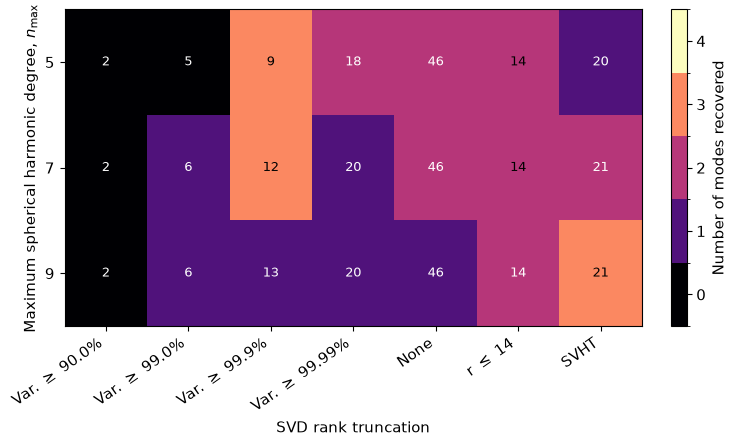

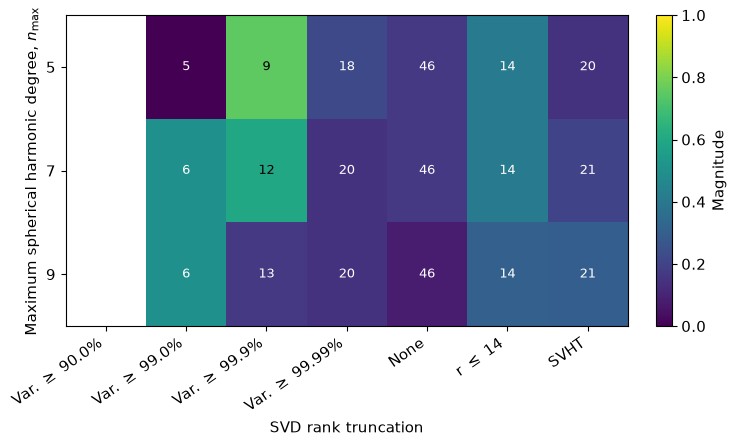

In [15]:


# nmax values to test
nmax_list = [5, 7, 9]
# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 14, 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)


dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":3,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}

Rank_Degree_Heatmap({"resolved":gnm_background}, control_modes, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings, syn_record=False)

        

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def Plot_Mode_Phasors(
    mode_suite,
    state_shape=state_shape,
    design_matrix=A_15_r,
    nmax=None,
    longitude=longitude,
    latitude=latitude,
    figure_width=text_width,
    font_size=11,
    cmap="seismic",
    scale="per_mode",
    sort_by_period=True,
):
    """
    Plot every mode phasor with:

        left column  = real component
        right column = imaginary component

    Supports mode dictionaries containing either:

        "gnm_phasor" : spherical-harmonic coefficient phasor

    or:

        "phasor" : already projected gridded physical-space phasor

    Period may be supplied as:

        "true_period"
        "period"

    or inferred from:

        "true_eigenvalue"
        "eigenvalue"

    Parameters
    ----------
    mode_suite : dict
        Synthetic-suite, control-suite, or similarly structured recovered-mode
        dictionary.

    state_shape : tuple
        Shape of one gridded spatial field, normally (n_latitude, n_longitude).

    design_matrix : ndarray
        Full radial-field design matrix, normally A_15_r.

    nmax : int or None
        Optional degree to which coefficient phasors should be truncated before
        projection. If None, the degree is inferred from each coefficient vector.

    scale : {"per_mode", "global"}
        "per_mode" gives each row its own symmetric colour scale.
        "global" uses one symmetric scale for the entire figure.

    Returns
    -------
    fig, axes
    """

    def get_period(mode_info):
        """Extract or calculate the mode period."""

        if "true_period" in mode_info:
            return float(mode_info["true_period"])

        if "period" in mode_info:
            return float(mode_info["period"])

        if "true_eigenvalue" in mode_info:
            eigenvalue = complex(mode_info["true_eigenvalue"])

        elif "eigenvalue" in mode_info:
            eigenvalue = complex(mode_info["eigenvalue"])

        else:
            return np.nan

        if np.isclose(eigenvalue.imag, 0.0):
            return np.inf

        return 2.0 * np.pi / np.abs(eigenvalue.imag)


    def infer_nmax_from_gauss(gauss_phasor):
        """Infer nmax from Ng = nmax * (nmax + 2)."""

        n_coefficients = np.asarray(gauss_phasor).size
        inferred_nmax = int(np.sqrt(n_coefficients + 1) - 1)

        expected_coefficients = inferred_nmax * (inferred_nmax + 2)

        if expected_coefficients != n_coefficients:
            raise ValueError(
                f"Cannot infer a complete spherical-harmonic degree from "
                f"{n_coefficients} coefficients."
            )

        return inferred_nmax


    def get_grid_phasor(mode_info):
        """Return one complex gridded physical-space phasor."""

        # Already in gridded physical space
        if "phasor" in mode_info:
            grid_phasor = np.asarray(
                mode_info["phasor"],
                dtype=complex,
            ).ravel()

        # Stored as Gauss coefficients
        elif "gnm_phasor" in mode_info:
            gauss_phasor = np.asarray(
                mode_info["gnm_phasor"],
                dtype=complex,
            ).ravel()

            available_nmax = infer_nmax_from_gauss(gauss_phasor)

            if nmax is None:
                nmax_used = available_nmax
            else:
                nmax_used = min(nmax, available_nmax)

            gauss_phasor = Truncate_Gauss_Coeffs(
                gauss_phasor,
                tmax=nmax_used,
            )

            A_used = Truncate_Gauss_Coeffs(
                design_matrix,
                tmax=nmax_used,
            )

            grid_phasor = A_used @ gauss_phasor

        else:
            raise KeyError(
                "Each mode must contain either 'phasor' or 'gnm_phasor'."
            )

        expected_size = np.prod(state_shape)

        if grid_phasor.size != expected_size:
            raise ValueError(
                f"Gridded phasor has length {grid_phasor.size}, "
                f"but state_shape={state_shape} requires {expected_size}."
            )

        return grid_phasor.reshape(state_shape)


    # Do not accidentally plot summary entries
    ignored_keys = {
        "match_count",
        "convergence_count",
    }

    mode_keys = [
        key
        for key, value in mode_suite.items()
        if (
            key not in ignored_keys
            and isinstance(value, dict)
            and (
                "phasor" in value
                or "gnm_phasor" in value
            )
        )
    ]

    if not mode_keys:
        raise ValueError(
            "No entries containing 'phasor' or 'gnm_phasor' were found."
        )

    periods = {
        key: get_period(mode_suite[key])
        for key in mode_keys
    }

    if sort_by_period:
        mode_keys = sorted(
            mode_keys,
            key=lambda key: periods[key],
        )

    grid_phasors = {
        key: get_grid_phasor(mode_suite[key])
        for key in mode_keys
    }

    n_modes = len(mode_keys)

    fig_height = max(
        2.0 * n_modes,
        0.65 * figure_width,
    )

    fig, axes = plt.subplots(
        nrows=n_modes,
        ncols=2,
        figsize=(figure_width, fig_height),
        squeeze=False,
        constrained_layout=True,
    )

    # Optional single global colour limit
    if scale == "global":
        global_limit = np.nanmax([
            np.nanmax(np.abs(grid_phasors[key].real))
            for key in mode_keys
        ] + [
            np.nanmax(np.abs(grid_phasors[key].imag))
            for key in mode_keys
        ])

    elif scale != "per_mode":
        raise ValueError(
            "scale must be either 'per_mode' or 'global'."
        )

    for row, mode_key in enumerate(mode_keys):

        phasor_grid = grid_phasors[mode_key]

        real_grid = phasor_grid.real
        imaginary_grid = phasor_grid.imag

        if scale == "per_mode":
            colour_limit = np.nanmax(
                np.abs(
                    np.concatenate([
                        real_grid.ravel(),
                        imaginary_grid.ravel(),
                    ])
                )
            )
        else:
            colour_limit = global_limit

        if not np.isfinite(colour_limit) or colour_limit == 0:
            colour_limit = 1.0

        period = periods[mode_key]

        if np.isfinite(period):
            period_text = f"Period = {period:.2f} years"
        else:
            period_text = "Static mode"

        real_image = axes[row, 0].pcolormesh(
            longitude,
            latitude,
            real_grid,
            shading="auto",
            cmap=cmap,
            vmin=-colour_limit,
            vmax=colour_limit,
        )

        axes[row, 1].pcolormesh(
            longitude,
            latitude,
            imaginary_grid,
            shading="auto",
            cmap=cmap,
            vmin=-colour_limit,
            vmax=colour_limit,
        )

        axes[row, 0].set_title(
            f"{mode_key}: real component\n{period_text}",
            fontsize=font_size,
        )

        axes[row, 1].set_title(
            f"{mode_key}: imaginary component\n{period_text}",
            fontsize=font_size,
        )

        for ax in axes[row, :]:
            ax.set_xlim(0, 360)
            ax.set_ylim(latitude.min(), latitude.max())
            ax.set_xlabel(
                "Longitude (°)",
                fontsize=font_size,
            )
            ax.tick_params(
                labelsize=font_size,
            )

        axes[row, 0].set_ylabel(
            "Latitude (°)",
            fontsize=font_size,
        )

        colourbar = fig.colorbar(
            real_image,
            ax=axes[row, :],
            location="right",
            shrink=0.85,
            pad=0.02,
        )

        colourbar.set_label(
            "SV amplitude",
            fontsize=font_size,
        )
        colourbar.ax.tick_params(
            labelsize=font_size,
        )

    return fig, axes

In [7]:
def Plot_Mode_Phasors(
    mode_suite,
    state_shape=state_shape,
    design_matrix=A_15_r,
    nmax=None,
    longitude=longitude,
    latitude=latitude,
    figure_width=text_width,
    font_size=11,
    cmap="seismic",
    scale="per_mode",
    sort_by_period=True,
):
    """
    Plot every mode phasor on Mollweide maps with:

        left column  = real component
        right column = imaginary component

    Supports mode dictionaries containing either:

        "gnm_phasor" : spherical-harmonic coefficient phasor

    or:

        "phasor" : already projected gridded physical-space phasor

    Period may be supplied as:

        "true_period"
        "period"

    or inferred from:

        "true_eigenvalue"
        "eigenvalue"

    Parameters
    ----------
    mode_suite : dict
        Synthetic-suite, control-suite, or similarly structured recovered-mode
        dictionary.

    state_shape : tuple
        Shape of one gridded field: (n_latitude, n_longitude).

    design_matrix : ndarray
        Full radial-field spherical-harmonic design matrix.

    nmax : int or None
        Degree to which coefficient phasors are truncated before projection.
        If None, use the full available degree.

    scale : {"per_mode", "global"}
        "per_mode":
            Each row has its own shared real/imaginary colour scale.

        "global":
            Every map uses one common colour scale.

    Returns
    -------
    fig, axes
    """

    longitude = np.asarray(longitude, dtype=float)
    latitude = np.asarray(latitude, dtype=float)

    if len(latitude) != state_shape[0]:
        raise ValueError(
            f"latitude has length {len(latitude)}, "
            f"but state_shape requires {state_shape[0]}."
        )

    if len(longitude) != state_shape[1]:
        raise ValueError(
            f"longitude has length {len(longitude)}, "
            f"but state_shape requires {state_shape[1]}."
        )

    def get_period(mode_info):
        """Extract or calculate the mode period."""

        if "true_period" in mode_info:
            return float(mode_info["true_period"])

        if "period" in mode_info:
            return float(mode_info["period"])

        if "true_eigenvalue" in mode_info:
            eigenvalue = complex(
                mode_info["true_eigenvalue"]
            )

        elif "eigenvalue" in mode_info:
            eigenvalue = complex(
                mode_info["eigenvalue"]
            )

        else:
            return np.nan

        if np.isclose(eigenvalue.imag, 0.0):
            return np.inf

        return (
            2.0 * np.pi
            / np.abs(eigenvalue.imag)
        )


    def infer_nmax_from_gauss(gauss_phasor):
        """Infer nmax from Ng = nmax(nmax + 2)."""

        n_coefficients = np.asarray(
            gauss_phasor
        ).size

        inferred_nmax = int(
            np.sqrt(n_coefficients + 1) - 1
        )

        expected_coefficients = (
            inferred_nmax
            * (inferred_nmax + 2)
        )

        if expected_coefficients != n_coefficients:
            raise ValueError(
                "Cannot infer a complete spherical-harmonic "
                f"degree from {n_coefficients} coefficients."
            )

        return inferred_nmax


    def get_grid_phasor(mode_info):
        """Return one complex physical-space phasor."""

        if "phasor" in mode_info:
            grid_phasor = np.asarray(
                mode_info["phasor"],
                dtype=complex,
            ).ravel()

        elif "gnm_phasor" in mode_info:
            gauss_phasor = np.asarray(
                mode_info["gnm_phasor"],
                dtype=complex,
            ).ravel()

            available_nmax = infer_nmax_from_gauss(
                gauss_phasor
            )

            if nmax is None:
                nmax_used = available_nmax
            else:
                nmax_used = min(
                    int(nmax),
                    available_nmax,
                )

            gauss_phasor = Truncate_Gauss_Coeffs(
                gauss_phasor,
                tmax=nmax_used,
            )

            A_used = Truncate_Gauss_Coeffs(
                design_matrix,
                tmax=nmax_used,
            )

            grid_phasor = (
                A_used @ gauss_phasor
            )

        else:
            raise KeyError(
                "Each mode must contain either "
                "'phasor' or 'gnm_phasor'."
            )

        expected_size = int(
            np.prod(state_shape)
        )

        if grid_phasor.size != expected_size:
            raise ValueError(
                f"Gridded phasor has length "
                f"{grid_phasor.size}, but "
                f"state_shape={state_shape} requires "
                f"{expected_size}."
            )

        return grid_phasor.reshape(
            state_shape
        )


    # --------------------------------------------------------------
    # Prepare Mollweide coordinates
    # --------------------------------------------------------------

    # Convert 0–360 degrees into -180–180 degrees.
    longitude_wrapped = (
        (longitude + 180.0) % 360.0
    ) - 180.0

    # Reorder longitude so it increases monotonically.
    longitude_order = np.argsort(
        longitude_wrapped
    )

    longitude_plot = longitude_wrapped[
        longitude_order
    ]

    longitude_radians = np.deg2rad(
        longitude_plot
    )

    latitude_radians = np.deg2rad(
        latitude
    )

    longitude_grid, latitude_grid = np.meshgrid(
        longitude_radians,
        latitude_radians,
    )

    # --------------------------------------------------------------
    # Identify valid mode entries
    # --------------------------------------------------------------

    ignored_keys = {
        "match_count",
        "convergence_count",
    }

    mode_keys = [
        key
        for key, value in mode_suite.items()
        if (
            key not in ignored_keys
            and isinstance(value, dict)
            and (
                "phasor" in value
                or "gnm_phasor" in value
            )
        )
    ]

    if not mode_keys:
        raise ValueError(
            "No entries containing 'phasor' or "
            "'gnm_phasor' were found."
        )

    periods = {
        key: get_period(mode_suite[key])
        for key in mode_keys
    }

    if sort_by_period:
        mode_keys = sorted(
            mode_keys,
            key=lambda key: periods[key],
        )

    grid_phasors = {}

    for key in mode_keys:
        phasor_grid = get_grid_phasor(
            mode_suite[key]
        )

        # Apply the same longitude ordering as the
        # wrapped Mollweide coordinates.
        grid_phasors[key] = (
            phasor_grid[:, longitude_order]
        )

    n_modes = len(mode_keys)

    # A Mollweide map naturally has an approximately 2:1 aspect ratio.
    fig_height = max(
        2.7 * n_modes,
        0.8 * figure_width,
    )

    fig, axes = plt.subplots(
        nrows=n_modes,
        ncols=2,
        figsize=(
            figure_width,
            fig_height,
        ),
        squeeze=False,
        subplot_kw={
            "projection": "mollweide",
        },
        constrained_layout=True,
    )

    # --------------------------------------------------------------
    # Establish colour limits
    # --------------------------------------------------------------

    if scale == "global":
        global_limit = np.nanmax([
            np.nanmax(
                np.abs(
                    grid_phasors[key].real
                )
            )
            for key in mode_keys
        ] + [
            np.nanmax(
                np.abs(
                    grid_phasors[key].imag
                )
            )
            for key in mode_keys
        ])

        if (
            not np.isfinite(global_limit)
            or global_limit == 0
        ):
            global_limit = 1.0

    elif scale != "per_mode":
        raise ValueError(
            "scale must be either "
            "'per_mode' or 'global'."
        )

    # --------------------------------------------------------------
    # Plot each mode
    # --------------------------------------------------------------

    for row, mode_key in enumerate(
        mode_keys
    ):
        phasor_grid = grid_phasors[
            mode_key
        ]

        real_grid = phasor_grid.real
        imaginary_grid = phasor_grid.imag

        if scale == "per_mode":
            colour_limit = np.nanmax(
                np.abs(
                    np.concatenate([
                        real_grid.ravel(),
                        imaginary_grid.ravel(),
                    ])
                )
            )

            if (
                not np.isfinite(colour_limit)
                or colour_limit == 0
            ):
                colour_limit = 1.0

        else:
            colour_limit = global_limit

        period = periods[mode_key]

        if np.isfinite(period):
            period_text = (
                f"Period = {period:.2f} years"
            )
        else:
            period_text = "Static mode"

        real_image = axes[row, 0].pcolormesh(
            longitude_grid,
            latitude_grid,
            real_grid,
            shading="auto",
            cmap=cmap,
            vmin=-colour_limit,
            vmax=colour_limit,
            rasterized=True,
        )

        axes[row, 1].pcolormesh(
            longitude_grid,
            latitude_grid,
            imaginary_grid,
            shading="auto",
            cmap=cmap,
            vmin=-colour_limit,
            vmax=colour_limit,
            rasterized=True,
        )

        axes[row, 0].set_title(
            (
                f"{mode_key}: real component\n"
                f"{period_text}"
            ),
            fontsize=font_size,
            pad=10,
        )

        axes[row, 1].set_title(
            (
                f"{mode_key}: imaginary component\n"
                f"{period_text}"
            ),
            fontsize=font_size,
            pad=10,
        )

        for ax in axes[row, :]:
            ax.grid(
                True,
                linestyle=":",
                linewidth=0.6,
                alpha=0.5,
            )

            ax.tick_params(
                labelsize=font_size - 1,
            )

        colourbar = fig.colorbar(
            real_image,
            ax=axes[row, :],
            location="right",
            shrink=0.8,
            pad=0.03,
        )

        colourbar.set_label(
            "SV amplitude",
            fontsize=font_size,
        )

        colourbar.ax.tick_params(
            labelsize=font_size - 1,
        )

    return fig, axes

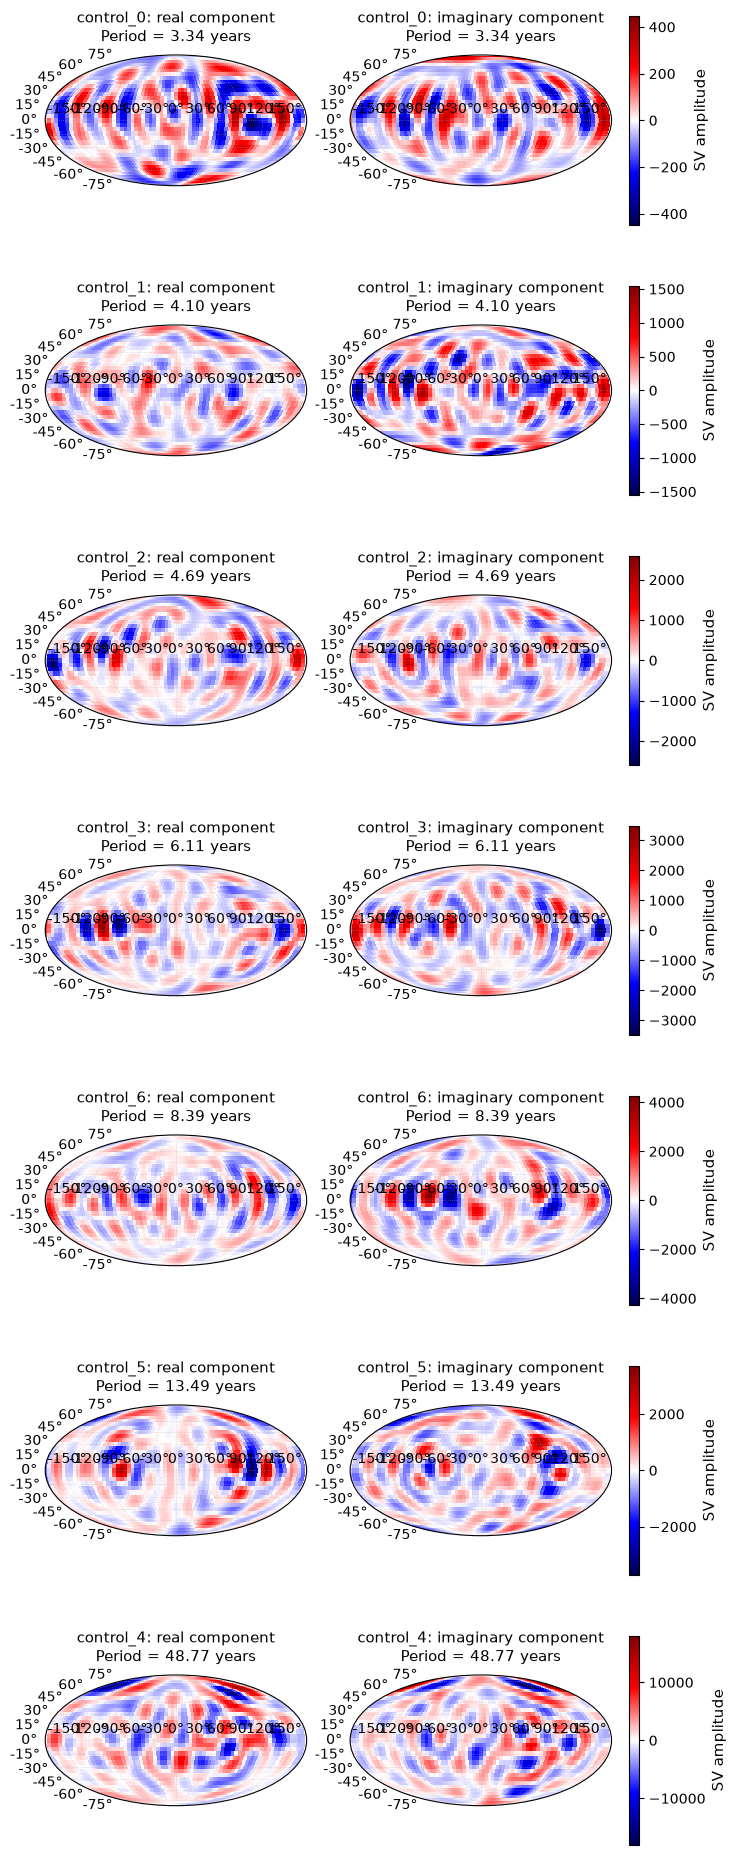

In [67]:
fig, axes = Plot_Mode_Phasors(
    control_modes,
    nmax=11,
)

plt.show()

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from pathlib import Path


def Plot_Mode_Suite_Video_Mollweide(
    mode_suite,
    times_used_relative,
    output_path,
    mode_keys=None,
    state_shape=state_shape,
    longitude=longitude,
    latitude=latitude,
    design_matrix=A_15_r,
    nmax=None,
    fps=5,
    dpi=150,
    figure_width=10,
    cmap="seismic",
    scale="per_mode",
    show_colorbars=False,
    sort_by_period=True,
    font_size=11,
):
    """
    Create one video showing the real reconstructed field for several modes,
    with one Mollweide subplot per row.

    Each row shows:
        x(t) = Re[ phasor * exp(eigenvalue * t) ]

    Compatible with dictionaries containing either:
        - 'gnm_phasor' and 'true_eigenvalue'
        - 'phasor' and 'eigenvalue'

    Period may be stored as:
        - 'true_period'
        - 'period'
    """

    times = np.asarray(times_used_relative, dtype=float).ravel()
    if times.size == 0:
        raise ValueError("times_used_relative is empty.")

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    expected_grid_size = int(np.prod(state_shape))

    # ------------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------------

    def infer_nmax_from_gauss(gauss_phasor):
        n_coefficients = np.asarray(gauss_phasor).size
        inferred_nmax = int(np.sqrt(n_coefficients + 1) - 1)
        expected_coefficients = inferred_nmax * (inferred_nmax + 2)

        if expected_coefficients != n_coefficients:
            raise ValueError(
                f"Cannot infer nmax from {n_coefficients} coefficients."
            )

        return inferred_nmax

    def get_eigenvalue(mode_info):
        if "true_eigenvalue" in mode_info:
            return complex(mode_info["true_eigenvalue"])
        if "eigenvalue" in mode_info:
            return complex(mode_info["eigenvalue"])

        raise KeyError(
            "Mode entry must contain 'true_eigenvalue' or 'eigenvalue'."
        )

    def get_period(mode_info, eigenvalue):
        if "true_period" in mode_info:
            return float(mode_info["true_period"])
        if "period" in mode_info:
            return float(mode_info["period"])

        if np.isclose(eigenvalue.imag, 0.0):
            return np.inf

        return 2.0 * np.pi / np.abs(eigenvalue.imag)

    def get_grid_phasor(mode_info):
        if "gnm_phasor" in mode_info:
            gauss_phasor = np.asarray(
                mode_info["gnm_phasor"],
                dtype=complex,
            ).ravel()

            available_nmax = infer_nmax_from_gauss(gauss_phasor)

            if nmax is None:
                nmax_used = available_nmax
            else:
                nmax_used = min(int(nmax), available_nmax)

            gauss_phasor = Truncate_Gauss_Coeffs(
                gauss_phasor,
                tmax=nmax_used,
            )

            A_used = Truncate_Gauss_Coeffs(
                design_matrix,
                tmax=nmax_used,
            )

            grid_phasor = A_used @ gauss_phasor

        elif "phasor" in mode_info:
            grid_phasor = np.asarray(
                mode_info["phasor"],
                dtype=complex,
            ).ravel()

        else:
            raise KeyError(
                "Mode entry must contain either 'gnm_phasor' or 'phasor'."
            )

        if grid_phasor.size != expected_grid_size:
            raise ValueError(
                f"Mode phasor has length {grid_phasor.size}, "
                f"but expected {expected_grid_size}."
            )

        return grid_phasor

    # ------------------------------------------------------------------
    # Select valid modes
    # ------------------------------------------------------------------

    ignored_keys = {"match_count", "convergence_count"}

    valid_mode_keys = [
        key
        for key, value in mode_suite.items()
        if (
            key not in ignored_keys
            and isinstance(value, dict)
            and ("phasor" in value or "gnm_phasor" in value)
        )
    ]

    if mode_keys is None:
        mode_keys = valid_mode_keys
    else:
        mode_keys = list(mode_keys)

    if len(mode_keys) == 0:
        raise ValueError("No valid modes were found.")

    # ------------------------------------------------------------------
    # Prepare longitude ordering for Mollweide
    # ------------------------------------------------------------------

    # Convert 0..360 to -180..180 and sort for proper Mollweide display
    lon_wrapped_deg = ((np.asarray(longitude) + 180) % 360) - 180
    lon_sort_idx = np.argsort(lon_wrapped_deg)
    lon_plot_deg = lon_wrapped_deg[lon_sort_idx]
    lat_plot_deg = np.asarray(latitude)

    lon_plot_rad = np.deg2rad(lon_plot_deg)
    lat_plot_rad = np.deg2rad(lat_plot_deg)

    lon2d, lat2d = np.meshgrid(lon_plot_rad, lat_plot_rad)

    # ------------------------------------------------------------------
    # Build mode cubes
    # ------------------------------------------------------------------

    mode_data = {}

    for mode_key in mode_keys:
        mode_info = mode_suite[mode_key]

        eigenvalue = get_eigenvalue(mode_info)
        period = get_period(mode_info, eigenvalue)
        phasor = get_grid_phasor(mode_info)

        physical_series = np.real(
            phasor[None, :] * np.exp(eigenvalue * times[:, None])
        )

        physical_cube = physical_series.reshape(
            len(times),
            *state_shape,
        )

        # reorder longitude dimension for Mollweide
        physical_cube = physical_cube[:, :, lon_sort_idx]

        mode_data[mode_key] = {
            "eigenvalue": eigenvalue,
            "period": period,
            "cube": physical_cube,
        }

    if sort_by_period:
        mode_keys = sorted(
            mode_keys,
            key=lambda k: mode_data[k]["period"]
        )

    # ------------------------------------------------------------------
    # Colour scales
    # ------------------------------------------------------------------

    if scale == "per_mode":
        colour_limits = {
            key: np.nanmax(np.abs(mode_data[key]["cube"]))
            for key in mode_keys
        }
    elif scale == "global":
        global_limit = np.nanmax([
            np.nanmax(np.abs(mode_data[key]["cube"]))
            for key in mode_keys
        ])
        colour_limits = {key: global_limit for key in mode_keys}
    else:
        raise ValueError("scale must be 'per_mode' or 'global'.")

    for key in mode_keys:
        if not np.isfinite(colour_limits[key]) or colour_limits[key] == 0:
            colour_limits[key] = 1.0

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------

    n_modes = len(mode_keys)
    fig_height = 3.2 * n_modes

    fig = plt.figure(figsize=(figure_width, fig_height))

    axes = []
    meshes = []

    for i, mode_key in enumerate(mode_keys):
        ax = fig.add_subplot(
            n_modes,
            1,
            i + 1,
            projection="mollweide",
        )
        axes.append(ax)

        cube = mode_data[mode_key]["cube"]
        period = mode_data[mode_key]["period"]
        sigma = mode_data[mode_key]["eigenvalue"].real
        clim = colour_limits[mode_key]

        mesh = ax.pcolormesh(
            lon2d,
            lat2d,
            cube[0],
            shading="auto",
            cmap=cmap,
            vmin=-clim,
            vmax=clim,
        )
        meshes.append(mesh)

        if np.isfinite(period):
            period_text = f"{period:.2f} yr"
        else:
            period_text = "static"

        ax.set_title(
            f"{mode_key}   |   Period = {period_text}   |   σ = {sigma:.3f} yr$^{{-1}}$",
            fontsize=font_size,
            pad=12,
        )

        ax.grid(True, alpha=0.4)

        if show_colorbars:
            cbar = fig.colorbar(
                mesh,
                ax=ax,
                orientation="horizontal",
                pad=0.08,
                fraction=0.05,
            )
            cbar.ax.tick_params(labelsize=font_size - 1)

    time_text = fig.suptitle(
        f"t = {times[0]:.2f} years",
        fontsize=font_size + 1,
        y=0.995,
    )

    fig.subplots_adjust(
        left=0.05,
        right=0.95,
        top=0.97,
        bottom=0.03,
        hspace=0.30,
    )

    # ------------------------------------------------------------------
    # Animation
    # ------------------------------------------------------------------

    def update(frame):
        for mode_key, mesh in zip(mode_keys, meshes):
            data = mode_data[mode_key]["cube"][frame]
            mesh.set_array(data.ravel())

        time_text.set_text(f"t = {times[frame]:.2f} years")
        return meshes + [time_text]

    animation = FuncAnimation(
        fig,
        update,
        frames=len(times),
        interval=1000 / fps,
        blit=False,
    )

    writer = FFMpegWriter(fps=fps)
    animation.save(output_path, writer=writer, dpi=dpi)

    plt.close(fig)

    print(f"Saved video to: {output_path}")

    return output_path

In [64]:
Plot_Mode_Suite_Video_Mollweide(
    mode_suite=control_modes,
    times_used_relative=times_used_relative,
    output_path=FIG_DIR / "control_modes_mollweide_nmax15_looking_for_long.mp4",
    mode_keys=control_modes.keys(),
    fps=5,
    figure_width=10,
    scale="per_mode",
    show_colorbars=False,
    nmax=nmax_control
)

Saved video to: /home/elliott/projects/msc_thesis_project/figures/control_modes_mollweide_nmax15_looking_for_long.mp4


PosixPath('/home/elliott/projects/msc_thesis_project/figures/control_modes_mollweide_nmax15_looking_for_long.mp4')

In [68]:
# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":9,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"resolved"
}

nmax_choice = 11
svd_rank_choice = 0.9999

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run({"resolved":gnm_background}, control_modes, dmd_settings, nmax_choice, svd_rank_choice,
                                       ensemble_settings, syn_record=False, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, control_modes)



/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 342859.4885331441. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1402: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)


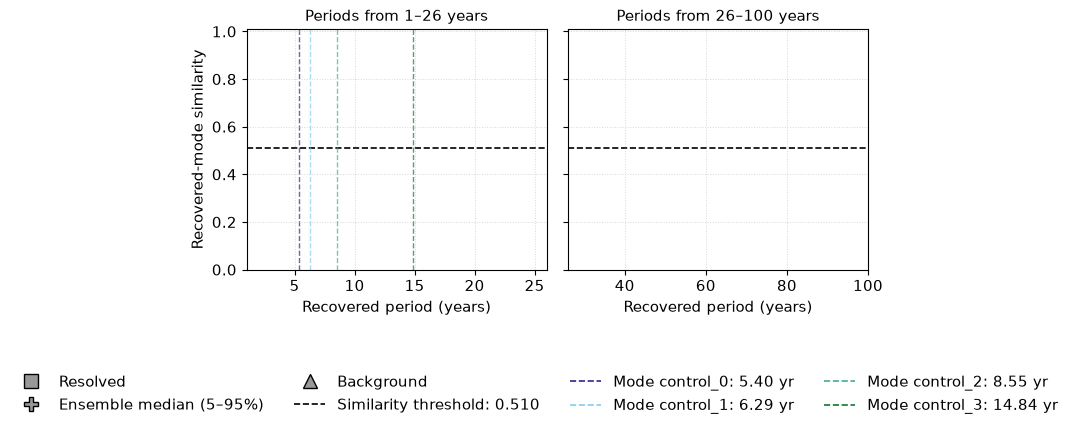

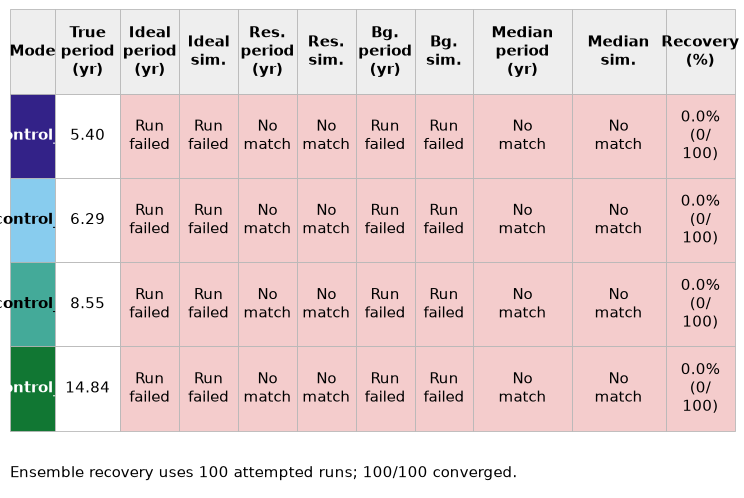

In [44]:
# getting results for a targeted run

similarity_threshold = similarity_thresholds[
    "full_match"
][str(nmax_choice)]

records_to_include = ["ideal","resolved","background","median"]

similarity_figure, similarity_axes = Plot_Period_Similarity_Results(
    results_dict, control_modes, similarity_threshold,
    record_markers, record_plotting_params, figure_width=text_width,
)

summary_figure, summary_table = Results_Summary_Table(results_dict, control_modes,
    records_to_include=records_to_include, ensemble_percentage_basis="attempted",
)
plt.show()

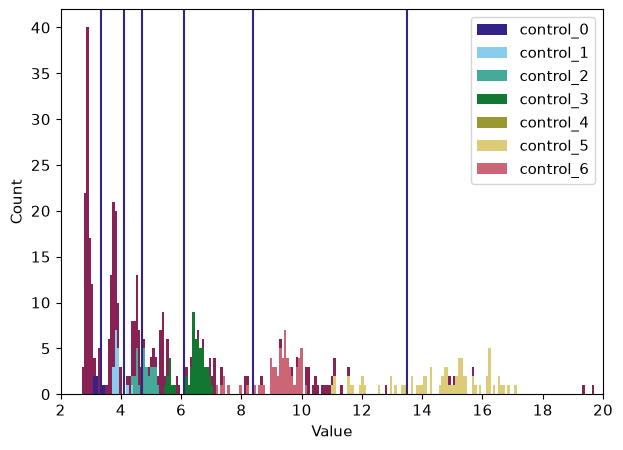

In [71]:
# from ensemble result, get period points by match
def By_Mode_Results(results_dict, mode_numbers):

    mode_period_recoveries = {}

    for mode_key in mode_numbers:
        mode_period_recoveries[mode_key] = []


    ensemble_result_dict = results_dict["ensemble"]

    for ensemble_i_key in ensemble_result_dict:
        ensemble_i_dict = ensemble_result_dict[ensemble_i_key]
        for mode_key in ensemble_i_dict:
            if ensemble_i_dict[mode_key] and type(ensemble_i_dict[mode_key])!=int:

                period = ensemble_i_dict[mode_key]["match_period"]
                mode_period_recoveries[mode_key].append(period)


    return(mode_period_recoveries)

by_mode_period_recoveries = By_Mode_Results(results_dict, control_modes.keys())

mode_keys = list(control_modes.keys())
values = [by_mode_period_recoveries[key] for key in mode_keys] + [total_unmatched_periods]

plt.figure(figsize=(7, 5))

plt.hist(
    values,
    bins=1000,
    stacked=True,
    label=mode_keys,
    range=(2, 80)
)

plt.xlim((2, 20))

for mode_key in control_modes:
    plt.axvline(control_modes[mode_key]["period"])

plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

In [99]:
# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":5,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"resolved"
}

nmax_choice = 9
svd_rank_choice = 0.999

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run({"resolved":gnm_background}, control_modes, dmd_settings, nmax_choice, svd_rank_choice,
                                       ensemble_settings, syn_record=False, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, control_modes)

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 127215.81453189878. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


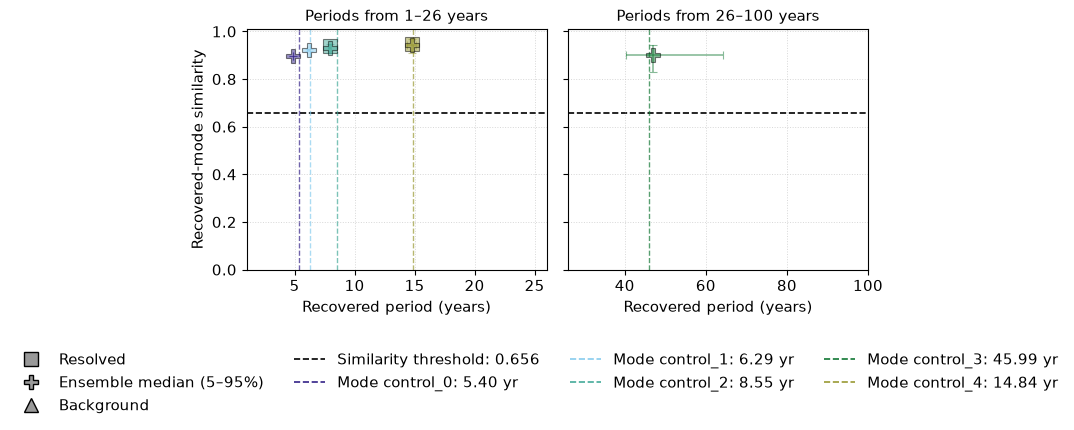

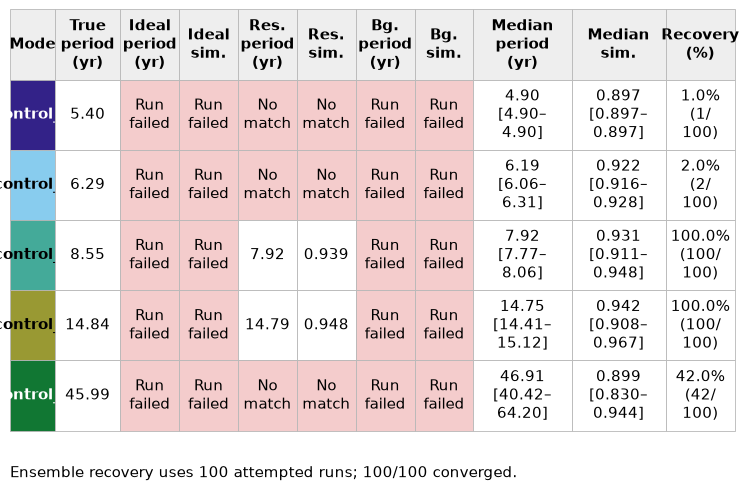

In [100]:
# getting results for a targeted run

similarity_threshold = similarity_thresholds[
    "full_match"
][str(nmax_choice)]

records_to_include = ["ideal","resolved","background","median"]

similarity_figure, similarity_axes = Plot_Period_Similarity_Results(
    results_dict, control_modes, similarity_threshold,
    record_markers, record_plotting_params, figure_width=text_width,
)

summary_figure, summary_table = Results_Summary_Table(results_dict, control_modes,
    records_to_include=records_to_include, ensemble_percentage_basis="attempted",
)
plt.show()

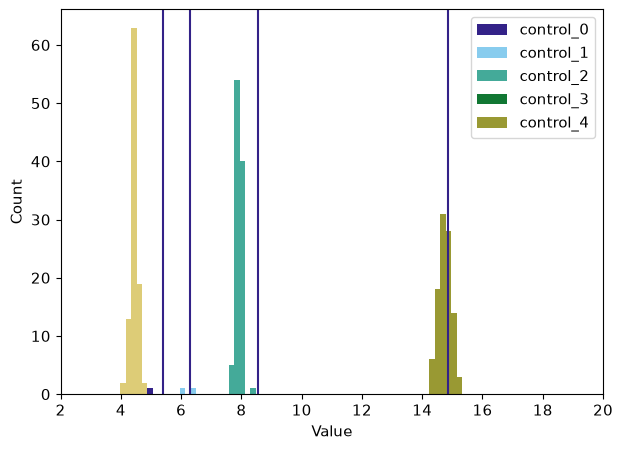

In [101]:
# from ensemble result, get period points by match
def By_Mode_Results(results_dict, mode_numbers):

    mode_period_recoveries = {}

    for mode_key in mode_numbers:
        mode_period_recoveries[mode_key] = []


    ensemble_result_dict = results_dict["ensemble"]

    for ensemble_i_key in ensemble_result_dict:
        ensemble_i_dict = ensemble_result_dict[ensemble_i_key]
        for mode_key in ensemble_i_dict:
            if ensemble_i_dict[mode_key] and type(ensemble_i_dict[mode_key])!=int:

                period = ensemble_i_dict[mode_key]["match_period"]
                mode_period_recoveries[mode_key].append(period)


    return(mode_period_recoveries)

by_mode_period_recoveries = By_Mode_Results(results_dict, control_modes.keys())

mode_keys = list(control_modes.keys())
values = [by_mode_period_recoveries[key] for key in mode_keys] + [total_unmatched_periods]

plt.figure(figsize=(7, 5))

plt.hist(
    values,
    bins=100,
    stacked=True,
    label=mode_keys,
    range=(2, 20)
)

for mode_key in control_modes:
    plt.axvline(control_modes[mode_key]["period"])
plt.xlim(2, 20)
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()